
MEDICAL COST PREDICTION



In [1]:
import kagglehub
path = kagglehub.dataset_download("mirichoi0218/insurance")

Using Colab cache for faster access to the 'insurance' dataset.


In [2]:
import os
import pandas as pd
print(os.listdir(path))
file_path = os.path.join(path, "insurance.csv")
df = pd.read_csv(file_path)
df

['insurance.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


NULL VALUES HANDLING

In [3]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


DUPLICATE VALUE HANDLING

In [4]:
df[df.duplicated()].shape

(1, 7)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df[df.duplicated()].shape

(0, 7)

In [7]:
df.shape

(1337, 7)

In [8]:
X=df.iloc[:,0:6]
Y=df.iloc[:,-1]

In [9]:
Y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


TRAIN TEST SPLIT

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

ENCODING

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_train['sex'] = le.fit_transform(X_train[['sex']])
X_train['smoker'] = le.fit_transform(X_train[['smoker']])
X_train['region'] = le.fit_transform(X_train[['region']])
X_test['sex'] = le.fit_transform(X_test[['sex']])
X_test['smoker'] = le.fit_transform(X_test[['smoker']])
X_test['region'] = le.fit_transform(X_test[['region']])

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

In [12]:
X_train

,age,sex,bmi,children,smoker,region
1114,23,1,24.510,0,0,0
968,21,1,25.745,2,0,0
599,52,0,37.525,2,0,1
170,63,1,41.470,0,0,2
275,47,0,26.600,2,0,0
...,...,...,...,...,...,...
1096,51,0,34.960,2,1,0
1131,27,1,45.900,2,0,3
1295,20,1,22.000,1,0,3
861,38,0,28.000,3,0,3


 STANDRIZATION

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['age']=scaler.fit_transform(df[['age']])
df['bmi']=scaler.fit_transform(df[['bmi']])
df['children']=scaler.fit_transform(df[['children']])
df['charges']=scaler.fit_transform(df[['charges']])

MODEL TRAIN

In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

PREDICTION

In [15]:
test_pred = model.predict(X_test)
train_pred=model.predict(X_train)


In [16]:
from sklearn.metrics import mean_squared_error, r2_score
train_mse = mean_squared_error(Y_train, train_pred)
train_r2 = r2_score(Y_train, train_pred)
test_mse = mean_squared_error(Y_test, test_pred)
test_r2 = r2_score(Y_test, test_pred)


In [17]:
print("Train MSE:", train_mse)
print("Train R2 Score:", train_r2)
print("Test MSE:", test_mse)
print("Test R2 Score:", test_r2)

Train MSE: 37005531.72811554
Train R2 Score: 0.7297182858804965
Test MSE: 35493102.61165051
Test R2 Score: 0.8068466322629112


In [18]:
from sklearn import metrics
from sklearn.metrics import mean_absolute_error
train_mae = mean_absolute_error(Y_train, train_pred)
test_mae = mean_absolute_error(Y_test, test_pred)
print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

Train MAE: 4181.3215781049175
Test MAE: 4182.353155288296


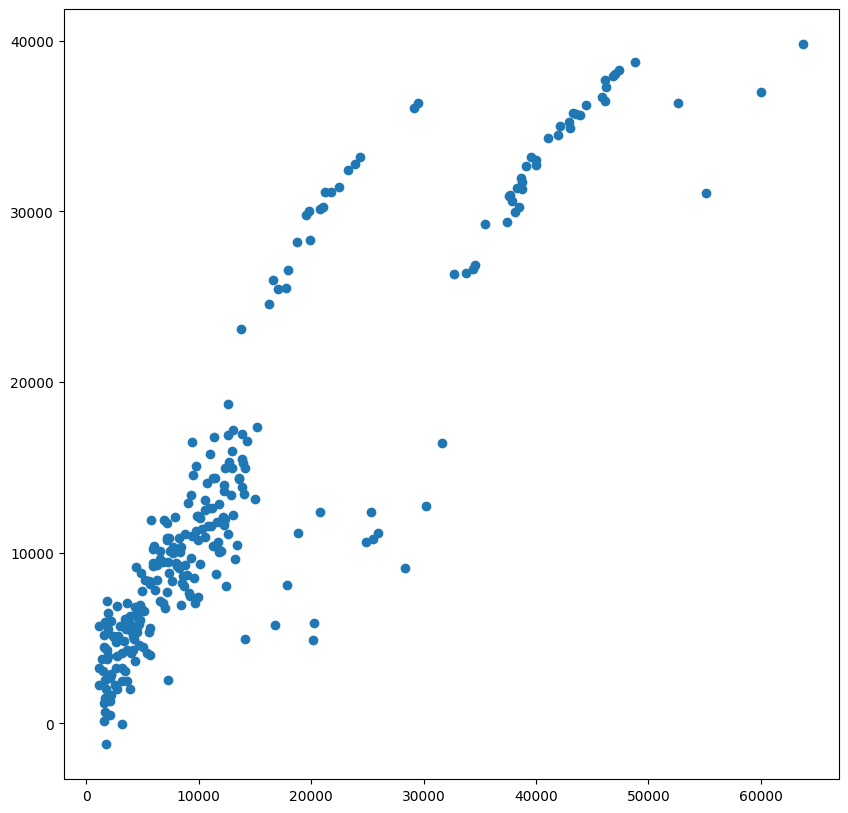

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))
plt.scatter(Y_test,test_pred)

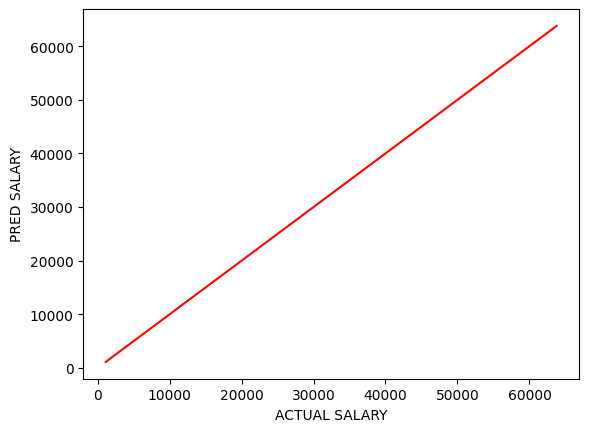

In [20]:
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],color='red')
plt.xlabel('ACTUAL SALARY')
plt.ylabel('PRED SALARY')
plt.show()

RIDGE

In [23]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
parameters={'alpha':[1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,55,100]}
ridge_regressor = GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [24]:
test_pred=ridge_regressor.predict(X_test)
train_pred=ridge_regressor.predict(X_train)
test_r2=r2_score(Y_test,test_pred)
train_r2=r2_score(Y_train,train_pred)
print('Train R2 Score:',train_r2)
print('Test R2 Score:',test_r2)

Train R2 Score: 0.7296971207298466
Test R2 Score: 0.8058993545084213


LASSO

In [25]:
from sklearn.linear_model import Lasso
lasso=Lasso()

In [26]:
parameters={'alpha':[0.01,0.05,0.1,0.2,0.3,0.5,0.6,1]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lasso_regressor.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.6, 1]},
             scoring='neg_mean_squared_error')

In [28]:
print(lasso_regressor.best_params_)


{'alpha': 1}


In [30]:
test_pred=lasso_regressor.predict(X_test)
train_pred=lasso_regressor.predict(X_train)
test_r2=r2_score(Y_test,test_pred)
train_r2=r2_score(Y_train,train_pred)
print('Train R2 Score:',train_r2)
print('Test R2 Score:',test_r2)

Train R2 Score: 0.7297181918821378
Test R2 Score: 0.8067959841661789


KNN

In [41]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=2)

In [42]:
knn.fit(X_train, Y_train)


KNeighborsRegressor(n_neighbors=2)

In [43]:
test_pred=knn.predict(X_test)
train_pred=knn.predict(X_train)
test_r2=r2_score(Y_test,test_pred)
train_r2=r2_score(Y_train,train_pred)
print('Train R2 Score:',train_r2)
print('Test R2 Score:',test_r2)

Train R2 Score: 0.6807864377908552
Test R2 Score: -0.037688227108886085


DECISION TREE

In [44]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()

In [45]:
dt.fit(X_train,Y_train)

DecisionTreeRegressor()

In [46]:
test_pred=dt.predict(X_test)
train_pred=dt.predict(X_train)
test_r2=r2_score(Y_test,test_pred)
train_r2=r2_score(Y_train,train_pred)
print('Train R2 Score:',train_r2)
print('Test R2 Score:',test_r2)

Train R2 Score: 1.0
Test R2 Score: 0.7701436766501689


RANDOM FOREST

In [48]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100, random_state=42)


In [49]:
rf.fit(X_train,Y_train)

RandomForestRegressor(random_state=42)

In [51]:
test_pred=rf.predict(X_test)
train_pred=rf.predict(X_train)
test_r2=r2_score(Y_test,test_pred)
train_r2=r2_score(Y_train,train_pred)
print('Train R2 Score:',train_r2)
print('Test R2 Score:',test_r2)

Train R2 Score: 0.9735877745820769
Test R2 Score: 0.8834278119122363


GRADIENT BOOST

In [70]:
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor(n_estimators=98)


In [71]:
gb.fit(X_train,Y_train)

GradientBoostingRegressor(n_estimators=98)

In [72]:
test_pred=gb.predict(X_test)
train_pred=gb.predict(X_train)
test_r2=r2_score(Y_test,test_pred)
train_r2=r2_score(Y_train,train_pred)
print('Train R2 Score:',train_r2)
print('Test R2 Score:',test_r2)

Train R2 Score: 0.892415783140835
Test R2 Score: 0.8999163807022001


Xgboost

In [73]:
from xgboost import XGBRegressor

In [84]:
model = XGBRegressor(
    n_estimators=95,       # number of boosting rounds
    learning_rate=0.1,      # step size shrinkage
    max_depth=5,            # max depth of trees
    subsample=0.8,          # fraction of samples per tree
    colsample_bytree=0.8,   # fraction of features per tree
    random_state=42,
    objective='reg:squarederror'  # regression loss
)

In [85]:
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=95,
             n_jobs=None, num_parallel_tree=None, ...)

In [86]:

test_pred=model.predict(X_test)
train_pred=model.predict(X_train)
test_r2=r2_score(Y_test,test_pred)
train_r2=r2_score(Y_train,train_pred)
print('Train R2 Score:',train_r2)
print('Test R2 Score:',test_r2)

Train R2 Score: 0.9355676513464164
Test R2 Score: 0.8879503136079716
